# Train a language model

In this notebook we train a small decoder-only transformer on the complete works of Shakespeare, one byte at a time, and then let it write. The model has the parts current open models use: RMSNorm, rotary position embeddings, grouped-query attention and a gated MLP. Dew builds it from the registry, `LMObjective` holds the next-token loss, and the same `Trainer` as the diffusion notebooks runs the training.

The notebook expects one NVIDIA GPU. It takes about four minutes on a Colab L4. The corpus is Tiny Shakespeare, 1.1 MB of text.

## Install

In [1]:
%pip install -q "dew-ml[cuda13] @ git+https://github.com/AshishKumar4/dew"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done


  Preparing metadata (pyproject.toml) ... done


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.1/532.1 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.9/216.9 kB 25.9 MB/s eta 0:00:00


## Settings

`SEQUENCE_LENGTH` is how many bytes the model sees at once. The model is 6 layers of width 384, about 14M parameters.

In [2]:
import os

SEQUENCE_LENGTH = 256
BATCH_SIZE = 64
STEPS = 1500
LEARNING_RATE = 1e-3
EMB_FEATURES = 384
NUM_LAYERS = 6
NUM_HEADS = 6
MAX_NEW_TOKENS = 400
PROMPT = "ROMEO:"
DATA_DIR = "data/05-shakespeare"
RUN_DIR = "runs/05-lm"
SEED = 0

# The tutorial test sets DEW_TUTORIAL_SMOKE=1 to run every cell in minutes on a CPU.
if os.environ.get("DEW_TUTORIAL_SMOKE") == "1":
    SEQUENCE_LENGTH, BATCH_SIZE, STEPS, EMB_FEATURES, NUM_LAYERS = 64, 8, 4, 64, 2


In [3]:
import json
import urllib.request
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

print(jax.devices())

[CudaDevice(id=0)]


## From text to tokens

A language model predicts the next token from the ones before it. The simplest tokenizer is the byte tokenizer: every byte of UTF-8 text is one token, so the vocabulary has 256 entries and needs no download. It makes sequences long, since every character is a token, but it is easy to read and fine for 1 MB of English.

Dew's token loader reads a folder with three files: `train.bin` and `val.bin`, the token ids as one flat array each, and `meta.json`, which says how to read them. We download the text, encode it, and keep the first 5% as validation.

In [4]:
from dew.data import ByteTokenizer

data_dir = Path(DATA_DIR)
data_dir.mkdir(parents=True, exist_ok=True)
text_path = data_dir / "input.txt"
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt", text_path)
text = text_path.read_text(encoding="utf-8")
print(text[:300])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


In [5]:
tokenizer = ByteTokenizer()
ids = np.asarray(tokenizer.encode(text), np.uint8)
val_len = len(ids) // 20
ids[:val_len].tofile(data_dir / "val.bin")
ids[val_len:].tofile(data_dir / "train.bin")
meta = {"tokenizer": "byte", "vocab_size": tokenizer.vocab_size, "dtype": "uint8",
        "train_tokens": len(ids) - val_len, "val_tokens": val_len, "eos_id": None}
(data_dir / "meta.json").write_text(json.dumps(meta, indent=2))
print(meta)

{'tokenizer': 'byte', 'vocab_size': 256, 'dtype': 'uint8', 'train_tokens': 1059625, 'val_tokens': 55769, 'eos_id': None}


`TokenWindows` cuts the training stream into windows of `SEQUENCE_LENGTH + 1` tokens. The first 256 ids of a window are the input and the same ids shifted by one are the targets, so every position learns to predict the byte after it. `val_batches=8` scores up to eight batches of validation windows at each evaluation; our validation split fills three.

In [6]:
from dew.data import DataPartition, Loading, TokenWindows

data = TokenWindows(
    path=DATA_DIR, seq_len=SEQUENCE_LENGTH, val_batches=8,
    loading=Loading(workers=0, threads=1, read_buffer=2),
).load(batch=BATCH_SIZE)
print("training windows:", data.records, "| steps per epoch:", data.steps_per_epoch)

batch = next(iter(data.train(DataPartition())))
print(batch["text"].shape)
print(repr(tokenizer.decode(batch["text"][0][:120])))

training windows: 4139 | steps per epoch: 64
(64, 257)
'u Kate,\nAnd bring you from a wild Kate to a Kate\nConformable as other household Kates.\nHere comes your father: never mak'


## The model

`models.build("causal_transformer", ...)` builds the decoder. `max_seq_len` sets the size of the KV cache used for generation, so it has to cover both a training window and the prompt plus every token we generate at the end. We compute in bfloat16 and keep the weights in float32. `dropout_rate=0.2` randomly zeroes a fifth of the activations during training. It slows memorisation, which matters here: 1 MB of text cuts into only about 4,000 training windows, and a model this size can learn them by heart.

In [7]:
from dew import models

model = models.build(
    "causal_transformer",
    vocab_size=meta["vocab_size"],
    emb_features=EMB_FEATURES,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    dropout_rate=0.2,
    max_seq_len=len(PROMPT) + MAX_NEW_TOKENS,
    dtype="bfloat16",
    attention_impl="auto",
)

## The objective and the trainer

`LMObjective` is next-token cross entropy. It shifts the batch into inputs and targets itself and computes the loss in float32. Like the diffusion objective, it keeps an EMA of the weights.

The learning rate warms up over the first 10% of steps and then decays along a cosine. `eval_every` runs the validation pass from the EMA weights, and `metrics.perplexity()` turns it into one number, which the next section explains.

In [8]:
import optax
from dew import Checkpoints, LocalTracker, Trainer, metrics
from dew.objectives.lm import LMObjective

objective = LMObjective(model, SEQUENCE_LENGTH, ema_decay=0.999)
schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0, peak_value=LEARNING_RATE,
    warmup_steps=STEPS // 10, decay_steps=STEPS, end_value=LEARNING_RATE / 10)
trainer = Trainer(
    objective, optax.adamw(schedule),
    key=jax.random.key(SEED),
    checkpoints=Checkpoints(RUN_DIR),
    tracker=LocalTracker(f"{RUN_DIR}/tracking"),
)

variables = jax.eval_shape(objective.init, jax.random.key(0))
n_params = sum(x.size for x in jax.tree_util.tree_leaves(variables["params"]))
print(f"{n_params / 1e6:.1f}M parameters")

14.3M parameters


## Training

In [9]:
state = trainer.fit(data, steps=STEPS, log_every=150, eval_every=500, checkpoint_every=STEPS,
                    metrics=(metrics.perplexity(),))

Training from step 0 to 1500 on {'data': 1, 'expert': 1, 'fsdp': 1, 'tensor': 1, 'sequence': 1, 'stage': 1} (1 process(es))


step 150: loss 2.0032


step 300: loss 1.5412


step 450: loss 1.4044


Evaluation val at step 500: 3 coordinated batches, 192 records, uneven_shards=False, event_key=(1753219770, 2831660841): {'val/perplexity': 11.98130281857004}


...

step 1050: loss 1.1233


step 1200: loss 1.1310


step 1350: loss 1.1093


step 1500: loss 1.0713
Evaluation val at step 1500: 3 coordinated batches, 192 records, uneven_shards=False, event_key=(352661883, 2305041505): {'val/perplexity': 4.1767878417399285}


Goodput: first step after 40.58 s, 67.6% of the wall time in steps


## Perplexity

Perplexity is $e^{\text{cross entropy}}$: roughly, how many tokens the model is choosing between at each position. An untrained byte model scores about 256, one guess out of every possible byte. The plot shows the training loss and the validation perplexity from the tracker's journal. Validation perplexity falls from about 12 at step 500 to about 4 at the end: the model has narrowed each next byte down to a handful of choices.

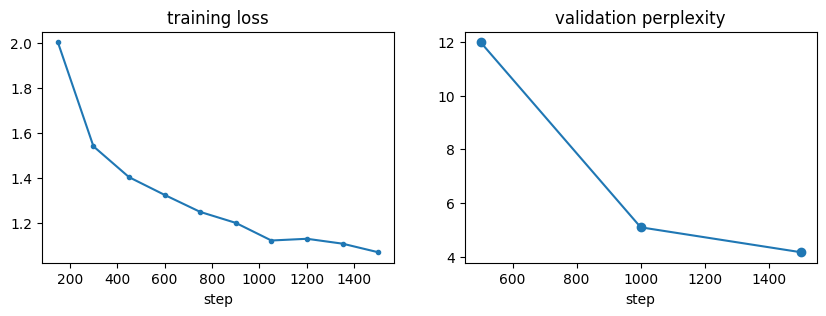

final validation perplexity: 4.18


In [10]:
rows = [json.loads(line) for line in open(f"{RUN_DIR}/tracking/scalars.jsonl")]
train = [(row["step"], row["scalars"]["train/loss"]) for row in rows if "train/loss" in row["scalars"]]
val = [(row["step"], row["scalars"]["val/perplexity"]) for row in rows if "val/perplexity" in row["scalars"]]

figure, (left, right) = plt.subplots(1, 2, figsize=(10, 3))
left.plot(*zip(*train), marker=".")
left.set(xlabel="step", title="training loss")
right.plot(*zip(*val), marker="o")
right.set(xlabel="step", title="validation perplexity")
plt.show()
print("final validation perplexity:", round(val[-1][1], 2))

## Generating text

A decoder writes one token at a time, and each new token attends to every token before it. The KV cache stores the keys and values of every earlier position, so the prompt runs through the model once and each later step runs only the newest token.

`generate` runs that loop compiled. `Sampling` sets the temperature and top-k: temperature 0 always takes the most likely byte, and higher temperatures pick more freely. We sample from the EMA weights, `state.averaged`.

In [11]:
from dew.sampling import Sampling, generate

prompt = jnp.asarray([tokenizer.encode(PROMPT)], jnp.int32)
out = generate(model, state.averaged, prompt, max_new_tokens=MAX_NEW_TOKENS,
               key=jax.random.key(1), sampling=Sampling(temperature=0.8, top_k=40))
print(tokenizer.decode(out.tokens[0]))

ROMEO:
Tut Tybalt, Gracious fazous to deparal,
Your bring shall be find that is in the sign,
Why both his hardy nundrest to an all ment.

RICHMOND:
Let must be, my lord, if you that day:
But yea, sir, then time and with himself;
Her oft protection to his death to the supper your
mother married to men.

HERMIONE:
And not that his by the duke a heaveness.

Third I change it another canst thou beast;
When 


Greedy decoding (temperature 0) always picks the most likely byte. It tends to fall into a loop, as it does below after one line, which is why sampling is usually preferred for text like this.

In [12]:
greedy = generate(model, state.averaged, prompt, max_new_tokens=200,
                  key=jax.random.key(0), sampling=Sampling(temperature=0.0))
print(tokenizer.decode(greedy.tokens[0]))

ROMEO:
The sear that shall be the seat of the seas,
And the strain the seat of the seat of the seas,
And the strain the seat of the seat of the seas,
And the straight the seat of the seat of the seas,
And t


## Reloading the checkpoint

`fit` wrote a checkpoint to `RUN_DIR` at the end of training: the weights, the EMA, the optimizer state, the step counters and the position in the data. A new `Trainer` over the same objective restores it with `place()`, and greedy decoding from the restored weights gives the same text.

In [13]:
restored, _, _ = Trainer(objective, optax.adamw(schedule), key=jax.random.key(SEED),
                         checkpoints=Checkpoints(RUN_DIR)).place()
again = generate(model, restored.averaged, prompt, max_new_tokens=200,
                 key=jax.random.key(0), sampling=Sampling(temperature=0.0))
print("restored step:", int(restored.step))
print("same greedy text:", bool(np.array_equal(again.tokens, greedy.tokens)))

Resumed from step 1500 in /content/nb/runs/05-lm
restored step: 1500
same greedy text: True


## Where to go next

`tools/tokenize_text.py` in the repository writes the same three token files for any text file or folder, with the byte tokenizer or a Hugging Face one. `recipes/lm/train.py` runs this training from the command line. [Notebook 07](07-scaling-on-many-devices.ipynb) trains this kind of model on several devices at once, and [notebook 08](08-load-a-pretrained-decoder.ipynb) starts from a pretrained decoder instead of random weights.